In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
DATA_DIR = Path("../data/raw")

print("Data directory:", DATA_DIR.resolve())


Data directory: C:\Users\sukhy\Desktop\smart-energy-project\data\raw


In [3]:
files = sorted(DATA_DIR.glob("*"))

for file in files:
    print(file.name)

AEP_hourly.csv
COMED_hourly.csv
DAYTON_hourly.csv
DEOK_hourly.csv
DOM_hourly.csv
DUQ_hourly.csv
EKPC_hourly.csv
est_hourly.paruqet
FE_hourly.csv
NI_hourly.csv
pjm_hourly_est.csv
PJM_Load_hourly.csv
PJME_hourly.csv
PJMW_hourly.csv


In [4]:
regions = [
    "AEP",
    "COMED",
    "DAYTON",
    "DEOK",
    "DOM",
    "DUQ",
    "EKPC",
    "FE",
    "NI",
    "PJME",
    "PJMW"
]

print("Number of regions:", len(regions))
print(regions)

Number of regions: 11
['AEP', 'COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'NI', 'PJME', 'PJMW']


In [5]:
data = {}

for region in regions:
    file_path = DATA_DIR / f"{region}_hourly.csv"
    data[region] = pd.read_csv(file_path)

print(f"Successfully loaded {len(data)} regional datasets.")

Successfully loaded 11 regional datasets.


In [6]:
print(f"Successfully loaded {len(data)} regional datasets.")

Successfully loaded 11 regional datasets.


In [7]:
data["PJME"].head()


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [8]:
data["PJME"].info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB


In [9]:
data["PJME"].describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [10]:
data["PJME"].head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [11]:
for region, df in data.items():
    print("=" * 60)
    print(f"REGION: {region}")
    print("Rows:", len(df))
    print("Columns:", list(df.columns))
    print("\nData types:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isna().sum())
    print()

REGION: AEP
Rows: 121273
Columns: ['Datetime', 'AEP_MW']

Data types:
Datetime        str
AEP_MW      float64
dtype: object

Missing values:
Datetime    0
AEP_MW      0
dtype: int64

REGION: COMED
Rows: 66497
Columns: ['Datetime', 'COMED_MW']

Data types:
Datetime        str
COMED_MW    float64
dtype: object

Missing values:
Datetime    0
COMED_MW    0
dtype: int64

REGION: DAYTON
Rows: 121275
Columns: ['Datetime', 'DAYTON_MW']

Data types:
Datetime         str
DAYTON_MW    float64
dtype: object

Missing values:
Datetime     0
DAYTON_MW    0
dtype: int64

REGION: DEOK
Rows: 57739
Columns: ['Datetime', 'DEOK_MW']

Data types:
Datetime        str
DEOK_MW     float64
dtype: object

Missing values:
Datetime    0
DEOK_MW     0
dtype: int64

REGION: DOM
Rows: 116189
Columns: ['Datetime', 'DOM_MW']

Data types:
Datetime        str
DOM_MW      float64
dtype: object

Missing values:
Datetime    0
DOM_MW      0
dtype: int64

REGION: DUQ
Rows: 119068
Columns: ['Datetime', 'DUQ_MW']

Data types:
D

In [12]:
for region, df in data.items():
    print(
        f"{region:7} | "
        f"Start: {df['Datetime'].min()} | "
        f"End: {df['Datetime'].max()}"
    )

AEP     | Start: 2004-10-01 01:00:00 | End: 2018-08-03 00:00:00
COMED   | Start: 2011-01-01 01:00:00 | End: 2018-08-03 00:00:00
DAYTON  | Start: 2004-10-01 01:00:00 | End: 2018-08-03 00:00:00
DEOK    | Start: 2012-01-01 01:00:00 | End: 2018-08-03 00:00:00
DOM     | Start: 2005-05-01 01:00:00 | End: 2018-08-03 00:00:00
DUQ     | Start: 2005-01-01 01:00:00 | End: 2018-08-03 00:00:00
EKPC    | Start: 2013-06-01 01:00:00 | End: 2018-08-03 00:00:00
FE      | Start: 2011-06-01 01:00:00 | End: 2018-08-03 00:00:00
NI      | Start: 2004-05-01 01:00:00 | End: 2011-01-01 00:00:00
PJME    | Start: 2002-01-01 01:00:00 | End: 2018-08-03 00:00:00
PJMW    | Start: 2002-04-01 01:00:00 | End: 2018-08-03 00:00:00


In [13]:
missing_summary = []

for region, df in data.items():
    missing_summary.append({
        "Region": region,
        "Total_Rows": len(df),
        "Missing_Datetime": df["Datetime"].isna().sum(),
        "Missing_Energy": df.iloc[:, 1].isna().sum()
    })

missing_df = pd.DataFrame(missing_summary)

missing_df

,Region,Total_Rows,Missing_Datetime,Missing_Energy
0,AEP,121273,0,0
1,COMED,66497,0,0
2,DAYTON,121275,0,0
3,DEOK,57739,0,0
4,DOM,116189,0,0
5,DUQ,119068,0,0
6,EKPC,45334,0,0
7,FE,62874,0,0
8,NI,58450,0,0
9,PJME,145366,0,0


In [14]:
duplicate_summary = []

for region, df in data.items():
    duplicate_summary.append({
        "Region": region,
        "Duplicate_Timestamps": df["Datetime"].duplicated().sum()
    })

duplicate_df = pd.DataFrame(duplicate_summary)

duplicate_df

,Region,Duplicate_Timestamps
0,AEP,4
1,COMED,4
2,DAYTON,4
3,DEOK,4
4,DOM,4
5,DUQ,4
6,EKPC,4
7,FE,4
8,NI,0
9,PJME,4


In [15]:
for region, df in data.items():
    temp = df.copy()
    temp["Datetime"] = pd.to_datetime(temp["Datetime"])
    temp = temp.sort_values("Datetime")

    diff = temp["Datetime"].diff()

    print("=" * 50)
    print(region)
    print(diff.value_counts().head(5))

AEP
Datetime
0 days 01:00:00    121241
0 days 02:00:00        27
0 days 00:00:00         4
Name: count, dtype: int64
COMED
Datetime
0 days 01:00:00    66481
0 days 02:00:00       11
0 days 00:00:00        4
Name: count, dtype: int64
DAYTON
Datetime
0 days 01:00:00    121245
0 days 02:00:00        25
0 days 00:00:00         4
Name: count, dtype: int64
DEOK
Datetime
0 days 01:00:00    57725
0 days 02:00:00        9
0 days 00:00:00        4
Name: count, dtype: int64
DOM
Datetime
0 days 01:00:00    116161
0 days 02:00:00        23
0 days 00:00:00         4
Name: count, dtype: int64
DUQ
Datetime
0 days 01:00:00    119039
0 days 02:00:00        24
0 days 00:00:00         4
Name: count, dtype: int64
EKPC
Datetime
0 days 01:00:00    45323
0 days 02:00:00        6
0 days 00:00:00        4
Name: count, dtype: int64
FE
Datetime
0 days 01:00:00    62859
0 days 02:00:00       10
0 days 00:00:00        4
Name: count, dtype: int64
NI
Datetime
0 days 01:00:00    58435
0 days 02:00:00       14
Name: co

In [16]:
missing_summary = []

for region, df in data.items():
    missing_summary.append({
        "Region": region,
        "Total_Rows": len(df),
        "Missing_Datetime": df["Datetime"].isna().sum(),
        "Missing_Energy": df.iloc[:, 1].isna().sum()
    })

missing_df = pd.DataFrame(missing_summary)

missing_df

,Region,Total_Rows,Missing_Datetime,Missing_Energy
0,AEP,121273,0,0
1,COMED,66497,0,0
2,DAYTON,121275,0,0
3,DEOK,57739,0,0
4,DOM,116189,0,0
5,DUQ,119068,0,0
6,EKPC,45334,0,0
7,FE,62874,0,0
8,NI,58450,0,0
9,PJME,145366,0,0


In [17]:
duplicate_summary = []

for region, df in data.items():
    duplicate_summary.append({
        "Region": region,
        "Duplicate_Timestamps": df["Datetime"].duplicated().sum()
    })

duplicate_df = pd.DataFrame(duplicate_summary)

duplicate_df

,Region,Duplicate_Timestamps
0,AEP,4
1,COMED,4
2,DAYTON,4
3,DEOK,4
4,DOM,4
5,DUQ,4
6,EKPC,4
7,FE,4
8,NI,0
9,PJME,4


In [18]:
for region, df in data.items():
    temp = df.copy()
    temp["Datetime"] = pd.to_datetime(temp["Datetime"])
    temp = temp.sort_values("Datetime")

    diff = temp["Datetime"].diff()

    print("=" * 50)
    print(region)
    print(diff.value_counts().head(5))

AEP
Datetime
0 days 01:00:00    121241
0 days 02:00:00        27
0 days 00:00:00         4
Name: count, dtype: int64
COMED
Datetime
0 days 01:00:00    66481
0 days 02:00:00       11
0 days 00:00:00        4
Name: count, dtype: int64
DAYTON
Datetime
0 days 01:00:00    121245
0 days 02:00:00        25
0 days 00:00:00         4
Name: count, dtype: int64
DEOK
Datetime
0 days 01:00:00    57725
0 days 02:00:00        9
0 days 00:00:00        4
Name: count, dtype: int64
DOM
Datetime
0 days 01:00:00    116161
0 days 02:00:00        23
0 days 00:00:00         4
Name: count, dtype: int64
DUQ
Datetime
0 days 01:00:00    119039
0 days 02:00:00        24
0 days 00:00:00         4
Name: count, dtype: int64
EKPC
Datetime
0 days 01:00:00    45323
0 days 02:00:00        6
0 days 00:00:00        4
Name: count, dtype: int64
FE
Datetime
0 days 01:00:00    62859
0 days 02:00:00       10
0 days 00:00:00        4
Name: count, dtype: int64
NI
Datetime
0 days 01:00:00    58435
0 days 02:00:00       14
Name: co

In [19]:
time_summary = []

for region, df in data.items():
    temp = df.copy()
    temp["Datetime"] = pd.to_datetime(temp["Datetime"])
    temp = temp.sort_values("Datetime")

    diff = temp["Datetime"].diff()

    time_summary.append({
        "Region": region,
        "Rows": len(temp),
        "1_Hour_Gaps": (diff == pd.Timedelta(hours=1)).sum(),
        "2_Hour_Gaps": (diff == pd.Timedelta(hours=2)).sum(),
        "Duplicate_Timestamps": (diff == pd.Timedelta(0)).sum(),
        "Other_Gaps": (
            (diff.notna()) &
            (diff != pd.Timedelta(hours=1)) &
            (diff != pd.Timedelta(hours=2)) &
            (diff != pd.Timedelta(0))
        ).sum()
    })

time_summary_df = pd.DataFrame(time_summary)

time_summary_df

,Region,Rows,1_Hour_Gaps,2_Hour_Gaps,Duplicate_Timestamps,Other_Gaps
0,AEP,121273,121241,27,4,0
1,COMED,66497,66481,11,4,0
2,DAYTON,121275,121245,25,4,0
3,DEOK,57739,57725,9,4,0
4,DOM,116189,116161,23,4,0
5,DUQ,119068,119039,24,4,0
6,EKPC,45334,45323,6,4,0
7,FE,62874,62859,10,4,0
8,NI,58450,58435,14,0,0
9,PJME,145366,145331,30,4,0


In [20]:
missing_summary = []

for region, df in data.items():
    energy_col = df.columns[1]

    missing_summary.append({
        "Region": region,
        "Rows": len(df),
        "Missing_Datetime": df["Datetime"].isna().sum(),
        "Missing_Energy": df[energy_col].isna().sum()
    })

missing_df = pd.DataFrame(missing_summary)

missing_df

,Region,Rows,Missing_Datetime,Missing_Energy
0,AEP,121273,0,0
1,COMED,66497,0,0
2,DAYTON,121275,0,0
3,DEOK,57739,0,0
4,DOM,116189,0,0
5,DUQ,119068,0,0
6,EKPC,45334,0,0
7,FE,62874,0,0
8,NI,58450,0,0
9,PJME,145366,0,0


In [21]:
negative_summary = []

for region, df in data.items():
    energy_col = df.columns[1]

    negative_summary.append({
        "Region": region,
        "Minimum_MW": df[energy_col].min(),
        "Negative_Values": (df[energy_col] < 0).sum(),
        "Maximum_MW": df[energy_col].max()
    })

negative_df = pd.DataFrame(negative_summary)

negative_df

,Region,Minimum_MW,Negative_Values,Maximum_MW
0,AEP,9581.0,0,25695.0
1,COMED,7237.0,0,23753.0
2,DAYTON,982.0,0,3746.0
3,DEOK,907.0,0,5445.0
4,DOM,1253.0,0,21651.0
5,DUQ,1014.0,0,3054.0
6,EKPC,514.0,0,3490.0
7,FE,0.0,0,14032.0
8,NI,7003.0,0,23631.0
9,PJME,14544.0,0,62009.0


In [22]:
analysis_data = {}

for region, df in data.items():
    temp = df.copy()
    temp["Datetime"] = pd.to_datetime(temp["Datetime"])
    
    energy_col = temp.columns[1]
    
    temp["Hour"] = temp["Datetime"].dt.hour
    temp["DayOfWeek"] = temp["Datetime"].dt.dayofweek
    temp["Month"] = temp["Datetime"].dt.month
    
    analysis_data[region] = temp

print("Analysis features created for all 11 regions.")


Analysis features created for all 11 regions.


In [23]:
pjme = analysis_data["PJME"]

hourly_pattern = pjme.groupby("Hour")["PJME_MW"].mean()

hourly_pattern

Hour
0     29523.611194
1     27535.589964
2     26344.055207
3     25679.097666
4     25414.924728
5     25749.431000
6     27162.853912
7     29611.046880
8     31490.827831
9     32628.888247
10    33497.403433
11    34197.643117
12    34588.618356
13    34759.571146
14    34916.601684
15    34940.669693
16    35065.392209
17    35596.051502
18    36421.931496
19    36426.629911
20    36106.840211
21    35741.057280
22    34453.149884
23    32047.501486
Name: PJME_MW, dtype: float64

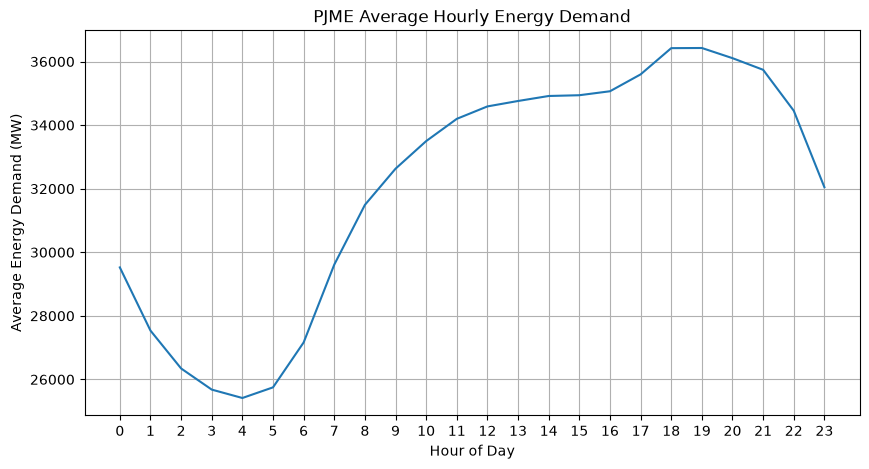

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(hourly_pattern.index, hourly_pattern.values)

plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Demand (MW)")
plt.title("PJME Average Hourly Energy Demand")

plt.xticks(range(24))
plt.grid(True)

plt.show()

In [25]:
weekly_pattern = pjme.groupby("DayOfWeek")["PJME_MW"].mean()

weekly_pattern

DayOfWeek
0    32672.028420
1    33272.265746
2    33261.497498
3    33085.857727
4    32688.097688
5    30162.880588
6    29411.869930
Name: PJME_MW, dtype: float64

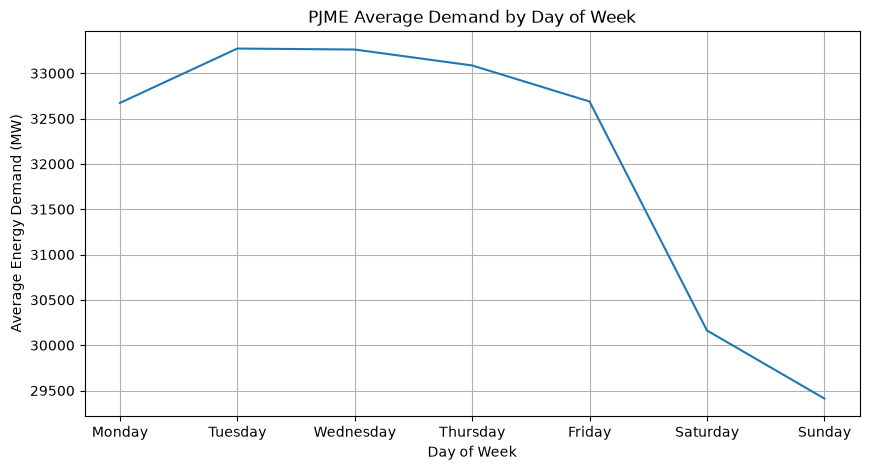

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(weekly_pattern.index, weekly_pattern.values)

plt.xlabel("Day of Week")
plt.ylabel("Average Energy Demand (MW)")
plt.title("PJME Average Demand by Day of Week")

plt.xticks(
    range(7),
    ["Monday", "Tuesday", "Wednesday", "Thursday",
     "Friday", "Saturday", "Sunday"]
)

plt.grid(True)

plt.show()

In [27]:
monthly_pattern = pjme.groupby("Month")["PJME_MW"].mean()

monthly_pattern

Month
1     34343.246462
2     33434.972049
3     30514.903609
4     27863.339354
5     28695.362113
6     33811.799183
7     37881.972881
8     36595.959675
9     31484.054688
10    28119.228675
11    29328.733872
12    32676.247669
Name: PJME_MW, dtype: float64

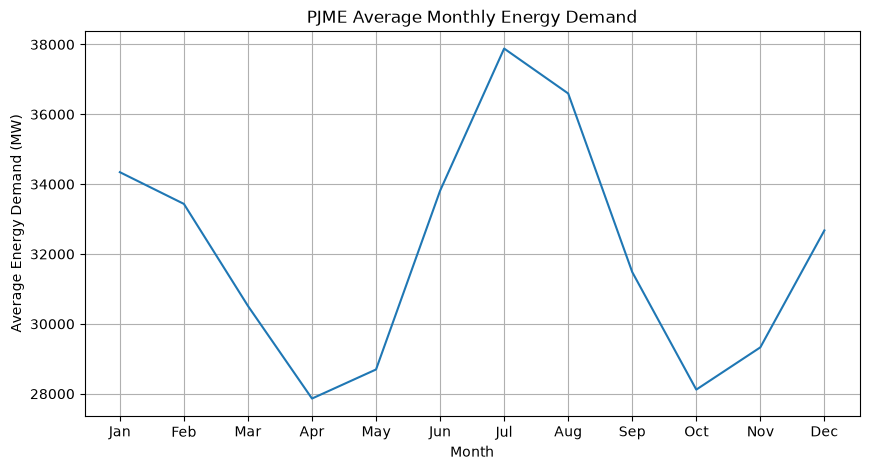

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_pattern.index, monthly_pattern.values)

plt.xlabel("Month")
plt.ylabel("Average Energy Demand (MW)")
plt.title("PJME Average Monthly Energy Demand")

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.grid(True)

plt.show()

In [29]:
cleaned_data = {}

for region, df in data.items():
    temp = df.copy()

    # Convert timestamp to datetime
    temp["Datetime"] = pd.to_datetime(temp["Datetime"])

    # Sort chronologically
    temp = temp.sort_values("Datetime").reset_index(drop=True)

    cleaned_data[region] = temp

print(f"Prepared {len(cleaned_data)} datasets for cleaning.")

Prepared 11 datasets for cleaning.


In [30]:
for region, df in cleaned_data.items():
    print(
        region,
        "→",
        df["Datetime"].dtype
    )

AEP → datetime64[us]
COMED → datetime64[us]
DAYTON → datetime64[us]
DEOK → datetime64[us]
DOM → datetime64[us]
DUQ → datetime64[us]
EKPC → datetime64[us]
FE → datetime64[us]
NI → datetime64[us]
PJME → datetime64[us]
PJMW → datetime64[us]


In [31]:
duplicate_check = []

for region, df in cleaned_data.items():
    duplicate_check.append({
        "Region": region,
        "Duplicate_Timestamps": df["Datetime"].duplicated().sum()
    })

duplicate_check_df = pd.DataFrame(duplicate_check)

duplicate_check_df

,Region,Duplicate_Timestamps
0,AEP,4
1,COMED,4
2,DAYTON,4
3,DEOK,4
4,DOM,4
5,DUQ,4
6,EKPC,4
7,FE,4
8,NI,0
9,PJME,4


In [32]:
for region, df in cleaned_data.items():

    duplicates = df[df["Datetime"].duplicated(keep=False)]

    if len(duplicates) > 0:
        print("=" * 60)
        print(region)
        print(duplicates.head(20))

AEP
                  Datetime   AEP_MW
88394  2014-11-02 02:00:00  12994.0
88395  2014-11-02 02:00:00  13190.0
97130  2015-11-01 02:00:00  10785.0
97131  2015-11-01 02:00:00  10542.0
106034 2016-11-06 02:00:00  10964.0
106035 2016-11-06 02:00:00  11008.0
114770 2017-11-05 02:00:00  10596.0
114771 2017-11-05 02:00:00  10446.0
COMED
                 Datetime  COMED_MW
33618 2014-11-02 02:00:00    9184.0
33619 2014-11-02 02:00:00    8869.0
42354 2015-11-01 02:00:00    8270.0
42355 2015-11-01 02:00:00    7923.0
51258 2016-11-06 02:00:00    8028.0
51259 2016-11-06 02:00:00    7814.0
59994 2017-11-05 02:00:00    8198.0
59995 2017-11-05 02:00:00    7878.0
DAYTON
                  Datetime  DAYTON_MW
88396  2014-11-02 02:00:00     1623.0
88397  2014-11-02 02:00:00     1634.0
97132  2015-11-01 02:00:00     1324.0
97133  2015-11-01 02:00:00     1292.0
106036 2016-11-06 02:00:00     1334.0
106037 2016-11-06 02:00:00     1364.0
114772 2017-11-05 02:00:00     1449.0
114773 2017-11-05 02:00:00     

In [33]:
dst_duplicate_summary = []

for region, df in cleaned_data.items():
    duplicates = df[df["Datetime"].duplicated(keep=False)].copy()

    dst_duplicate_summary.append({
        "Region": region,
        "Duplicate_Rows": len(duplicates),
        "Duplicate_Timestamps": duplicates["Datetime"].nunique(),
        "Dates_Affected": duplicates["Datetime"].dt.date.nunique()
    })

dst_duplicate_df = pd.DataFrame(dst_duplicate_summary)

dst_duplicate_df

,Region,Duplicate_Rows,Duplicate_Timestamps,Dates_Affected
0,AEP,8,4,4
1,COMED,8,4,4
2,DAYTON,8,4,4
3,DEOK,8,4,4
4,DOM,8,4,4
5,DUQ,8,4,4
6,EKPC,8,4,4
7,FE,8,4,4
8,NI,0,0,0
9,PJME,8,4,4


In [34]:
gap_summary = []

for region, df in cleaned_data.items():
    temp = df.sort_values("Datetime").copy()

    diff = temp["Datetime"].diff()

    gap_summary.append({
        "Region": region,
        "Rows": len(temp),
        "Two_Hour_Gaps": (diff == pd.Timedelta(hours=2)).sum(),
        "Large_Gaps": (
            diff.notna() &
            (diff > pd.Timedelta(hours=2))
        ).sum()
    })

gap_df = pd.DataFrame(gap_summary)

gap_df

,Region,Rows,Two_Hour_Gaps,Large_Gaps
0,AEP,121273,27,0
1,COMED,66497,11,0
2,DAYTON,121275,25,0
3,DEOK,57739,9,0
4,DOM,116189,23,0
5,DUQ,119068,24,0
6,EKPC,45334,6,0
7,FE,62874,10,0
8,NI,58450,14,0
9,PJME,145366,30,0


In [35]:
dst_duplicate_df

,Region,Duplicate_Rows,Duplicate_Timestamps,Dates_Affected
0,AEP,8,4,4
1,COMED,8,4,4
2,DAYTON,8,4,4
3,DEOK,8,4,4
4,DOM,8,4,4
5,DUQ,8,4,4
6,EKPC,8,4,4
7,FE,8,4,4
8,NI,0,0,0
9,PJME,8,4,4


In [36]:
missing_summary = []

for region, df in cleaned_data.items():

    energy_col = df.columns[1]

    missing_summary.append({
        "Region": region,
        "Missing_Datetime": df["Datetime"].isna().sum(),
        "Missing_Energy": df[energy_col].isna().sum(),
        "Total_Rows": len(df)
    })

missing_df = pd.DataFrame(missing_summary)

missing_df

,Region,Missing_Datetime,Missing_Energy,Total_Rows
0,AEP,0,0,121273
1,COMED,0,0,66497
2,DAYTON,0,0,121275
3,DEOK,0,0,57739
4,DOM,0,0,116189
5,DUQ,0,0,119068
6,EKPC,0,0,45334
7,FE,0,0,62874
8,NI,0,0,58450
9,PJME,0,0,145366


In [37]:
zero_summary = []

for region, df in cleaned_data.items():

    energy_col = df.columns[1]

    zero_summary.append({
        "Region": region,
        "Zero_Values": (df[energy_col] == 0).sum(),
        "Minimum_MW": df[energy_col].min()
    })

zero_df = pd.DataFrame(zero_summary)

zero_df

,Region,Zero_Values,Minimum_MW
0,AEP,0,9581.0
1,COMED,0,7237.0
2,DAYTON,0,982.0
3,DEOK,0,907.0
4,DOM,0,1253.0
5,DUQ,0,1014.0
6,EKPC,0,514.0
7,FE,1,0.0
8,NI,0,7003.0
9,PJME,0,14544.0


In [38]:
dst_duplicate_df

,Region,Duplicate_Rows,Duplicate_Timestamps,Dates_Affected
0,AEP,8,4,4
1,COMED,8,4,4
2,DAYTON,8,4,4
3,DEOK,8,4,4
4,DOM,8,4,4
5,DUQ,8,4,4
6,EKPC,8,4,4
7,FE,8,4,4
8,NI,0,0,0
9,PJME,8,4,4


In [39]:
missing_df

,Region,Missing_Datetime,Missing_Energy,Total_Rows
0,AEP,0,0,121273
1,COMED,0,0,66497
2,DAYTON,0,0,121275
3,DEOK,0,0,57739
4,DOM,0,0,116189
5,DUQ,0,0,119068
6,EKPC,0,0,45334
7,FE,0,0,62874
8,NI,0,0,58450
9,PJME,0,0,145366


In [40]:
zero_df

,Region,Zero_Values,Minimum_MW
0,AEP,0,9581.0
1,COMED,0,7237.0
2,DAYTON,0,982.0
3,DEOK,0,907.0
4,DOM,0,1253.0
5,DUQ,0,1014.0
6,EKPC,0,514.0
7,FE,1,0.0
8,NI,0,7003.0
9,PJME,0,14544.0


In [41]:
fe = cleaned_data["FE"]

energy_col = fe.columns[1]

fe_zero = fe[fe[energy_col] == 0]

fe_zero

,Datetime,FE_MW
0,2011-06-01 01:00:00,0.0


In [42]:
fe_zero_index = fe_zero.index[0]

fe.loc[
    max(0, fe_zero_index - 3):fe_zero_index + 3
]

,Datetime,FE_MW
0,2011-06-01 01:00:00,0.0
1,2011-06-01 02:00:00,8548.0
2,2011-06-01 03:00:00,8121.0
3,2011-06-01 04:00:00,7801.0


In [43]:
fe = cleaned_data["FE"].copy()

energy_col = fe.columns[1]

# Mark the invalid zero as missing
fe.loc[fe[energy_col] == 0, energy_col] = np.nan

# Calculate typical demand at the same hour of day
hour_median = fe.groupby(
    fe["Datetime"].dt.hour
)[energy_col].transform("median")

# Fill the invalid value
fe[energy_col] = fe[energy_col].fillna(hour_median)

cleaned_data["FE"] = fe

print(cleaned_data["FE"].head())

             Datetime   FE_MW
0 2011-06-01 01:00:00  6785.0
1 2011-06-01 02:00:00  8548.0
2 2011-06-01 03:00:00  8121.0
3 2011-06-01 04:00:00  7801.0
4 2011-06-01 05:00:00  7729.0


In [44]:
for region, df in cleaned_data.items():
    energy_col = df.columns[1]

    print(
        region,
        "missing =", df[energy_col].isna().sum(),
        "| zeros =", (df[energy_col] == 0).sum()
    )

AEP missing = 0 | zeros = 0
COMED missing = 0 | zeros = 0
DAYTON missing = 0 | zeros = 0
DEOK missing = 0 | zeros = 0
DOM missing = 0 | zeros = 0
DUQ missing = 0 | zeros = 0
EKPC missing = 0 | zeros = 0
FE missing = 0 | zeros = 0
NI missing = 0 | zeros = 0
PJME missing = 0 | zeros = 0
PJMW missing = 0 | zeros = 0


In [45]:
missing_df

,Region,Missing_Datetime,Missing_Energy,Total_Rows
0,AEP,0,0,121273
1,COMED,0,0,66497
2,DAYTON,0,0,121275
3,DEOK,0,0,57739
4,DOM,0,0,116189
5,DUQ,0,0,119068
6,EKPC,0,0,45334
7,FE,0,0,62874
8,NI,0,0,58450
9,PJME,0,0,145366


In [46]:
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

for region, df in cleaned_data.items():
    output_path = PROCESSED_DIR / f"{region}_cleaned.csv"
    df.to_csv(output_path, index=False)

print(f"Saved {len(cleaned_data)} cleaned regional datasets.")

Saved 11 cleaned regional datasets.
